# EDA with Data Visualization

**Purpose:** Explore SpaceX launch patterns using the charts required by the IBM lab.

> Starter template: complete this notebook using the corresponding IBM lab. Replace TODO sections with your actual code and outputs.

## Tasks

- [ ] Create required scatter plots
- [ ] Create required bar charts
- [ ] Analyze yearly trends
- [ ] Analyze launch sites/orbits/payloads
- [ ] Write interpretations for required charts

Dataset loaded successfully!
Rows: 90
Columns: 19


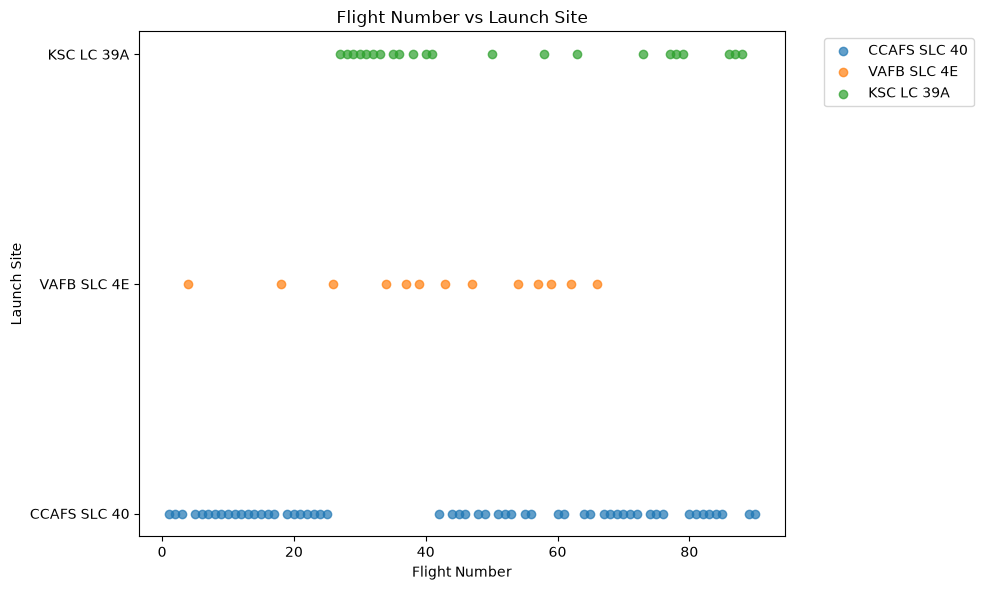

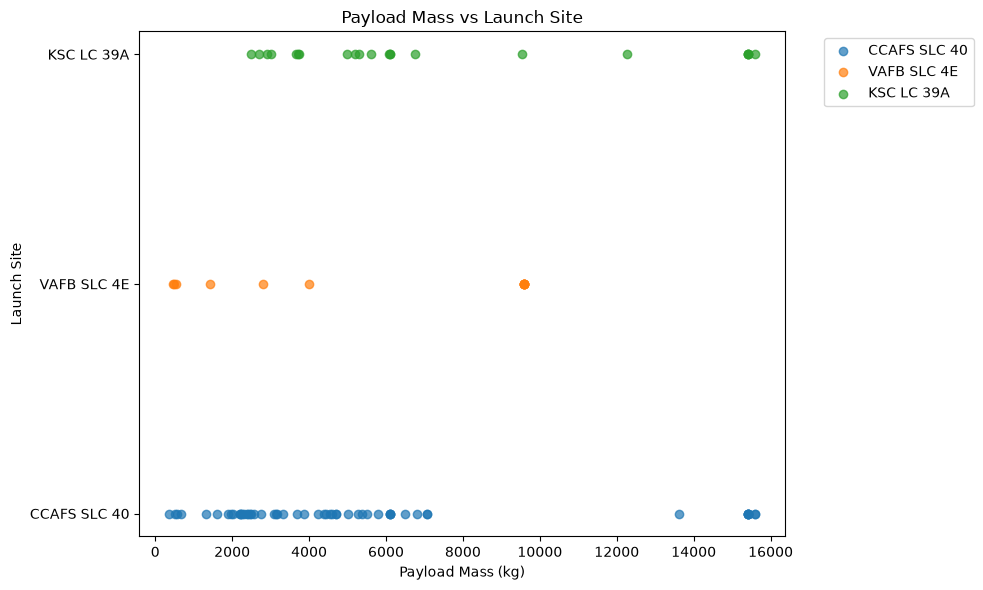

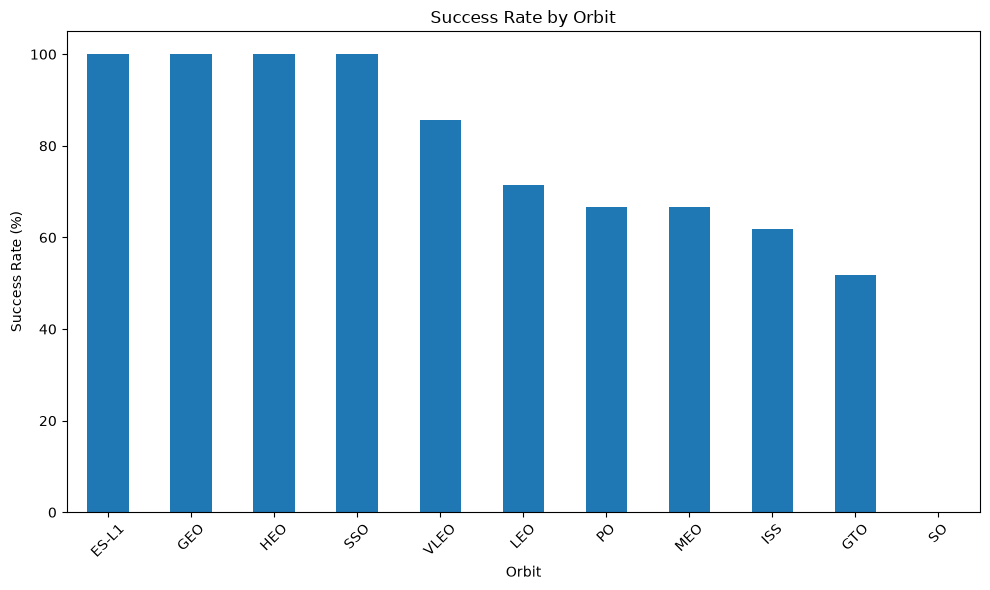

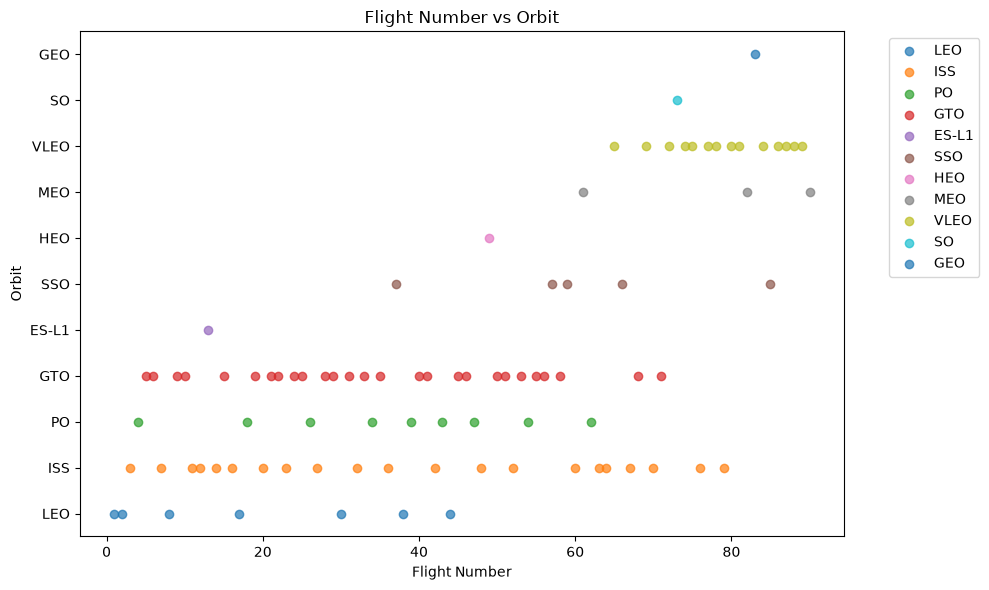

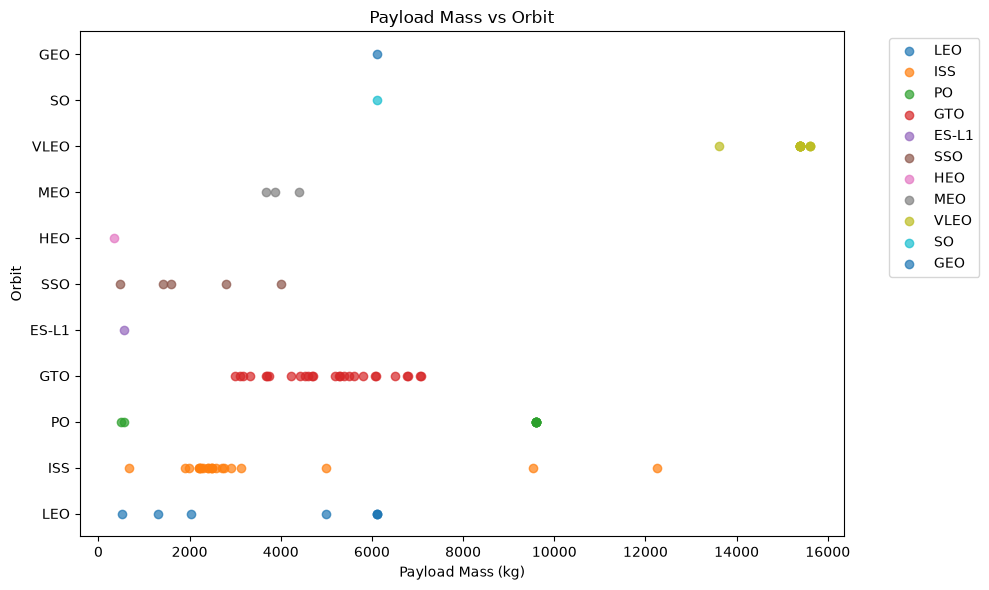


EDA RESULTS AND INSIGHTS

1. FLIGHT NUMBER VS LAUNCH SITE

Launch counts:
Launch_Site
CCAFS SLC 40    55
KSC LC 39A      22
VAFB SLC 4E     13
Name: count, dtype: int64

Insight: The flight numbers are distributed across multiple launch sites, showing that Falcon 9 missions have been conducted from different launch facilities over time.

2. PAYLOAD MASS VS LAUNCH SITE
              count     mean      max
Launch_Site                          
CCAFS SLC 40     55  5548.21  15600.0
KSC LC 39A       22  7606.45  15600.0
VAFB SLC 4E      13  5919.46   9600.0

Insight: Payload masses vary across launch sites, indicating that different launch facilities have supported missions with different payload requirements.

3. SUCCESS RATE BY ORBIT
Orbit
ES-L1    100.00
GEO      100.00
HEO      100.00
SSO      100.00
VLEO      85.71
LEO       71.43
PO        66.67
MEO       66.67
ISS       61.90
GTO       51.85
SO         0.00
Name: Class, dtype: float64

Insight: ES-L1 has the highest observed succe

In [2]:
# TODO: Add/import the libraries required by your IBM lab.
# ============================================================
# IBM APPLIED DATA SCIENCE CAPSTONE
# EDA WITH VISUALIZATION - REQUIRED 5 CHARTS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

df = pd.read_csv("spacex_dash.csv")

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

# ------------------------------------------------------------
# 2. STANDARDIZE COLUMN NAMES
# ------------------------------------------------------------

df = df.rename(columns={
    "BoosterVersion": "Booster_Version",
    "PayloadMass": "PAYLOAD_MASS__KG_",
    "LaunchSite": "Launch_Site",
    "FlightNumber": "Flight_Number"
})

# Convert required columns
df["PAYLOAD_MASS__KG_"] = pd.to_numeric(
    df["PAYLOAD_MASS__KG_"],
    errors="coerce"
)

df["Class"] = pd.to_numeric(
    df["Class"],
    errors="coerce"
)

df["Flight_Number"] = pd.to_numeric(
    df["Flight_Number"],
    errors="coerce"
)

# Create outputs folder
os.makedirs("outputs", exist_ok=True)


# ============================================================
# CHART 1
# FLIGHT NUMBER VS LAUNCH SITE
# ============================================================

plt.figure(figsize=(10, 6))

for site in df["Launch_Site"].dropna().unique():

    site_df = df[df["Launch_Site"] == site]

    plt.scatter(
        site_df["Flight_Number"],
        [site] * len(site_df),
        label=site,
        alpha=0.7
    )

plt.xlabel("Flight Number")
plt.ylabel("Launch Site")
plt.title("Flight Number vs Launch Site")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    "outputs/01_flight_number_vs_launch_site.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# CHART 2
# PAYLOAD MASS VS LAUNCH SITE
# ============================================================

plt.figure(figsize=(10, 6))

for site in df["Launch_Site"].dropna().unique():

    site_df = df[df["Launch_Site"] == site]

    plt.scatter(
        site_df["PAYLOAD_MASS__KG_"],
        [site] * len(site_df),
        label=site,
        alpha=0.7
    )

plt.xlabel("Payload Mass (kg)")
plt.ylabel("Launch Site")
plt.title("Payload Mass vs Launch Site")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "outputs/02_payload_mass_vs_launch_site.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# CHART 3
# SUCCESS RATE BY ORBIT
# ============================================================

orbit_success = (
    df.groupby("Orbit")["Class"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(10, 6))

orbit_success.plot(
    kind="bar"
)

plt.xlabel("Orbit")
plt.ylabel("Success Rate (%)")
plt.title("Success Rate by Orbit")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "outputs/03_success_rate_by_orbit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# CHART 4
# FLIGHT NUMBER VS ORBIT
# ============================================================

plt.figure(figsize=(10, 6))

for orbit in df["Orbit"].dropna().unique():

    orbit_df = df[df["Orbit"] == orbit]

    plt.scatter(
        orbit_df["Flight_Number"],
        [orbit] * len(orbit_df),
        label=orbit,
        alpha=0.7
    )

plt.xlabel("Flight Number")
plt.ylabel("Orbit")
plt.title("Flight Number vs Orbit")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "outputs/04_flight_number_vs_orbit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# CHART 5
# PAYLOAD MASS VS ORBIT
# ============================================================

plt.figure(figsize=(10, 6))

for orbit in df["Orbit"].dropna().unique():

    orbit_df = df[df["Orbit"] == orbit]

    plt.scatter(
        orbit_df["PAYLOAD_MASS__KG_"],
        [orbit] * len(orbit_df),
        label=orbit,
        alpha=0.7
    )

plt.xlabel("Payload Mass (kg)")
plt.ylabel("Orbit")
plt.title("Payload Mass vs Orbit")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "outputs/05_payload_mass_vs_orbit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PRINT NUMERICAL RESULTS + INSIGHTS
# ============================================================

print("\n" + "=" * 70)
print("EDA RESULTS AND INSIGHTS")
print("=" * 70)


# ----- Insight 1 -----

print("\n1. FLIGHT NUMBER VS LAUNCH SITE")

launch_counts = df["Launch_Site"].value_counts()

print("\nLaunch counts:")
print(launch_counts)

print(
    "\nInsight: The flight numbers are distributed across multiple "
    "launch sites, showing that Falcon 9 missions have been conducted "
    "from different launch facilities over time."
)


# ----- Insight 2 -----

print("\n2. PAYLOAD MASS VS LAUNCH SITE")

payload_by_site = (
    df.groupby("Launch_Site")["PAYLOAD_MASS__KG_"]
    .agg(["count", "mean", "max"])
    .round(2)
)

print(payload_by_site)

print(
    "\nInsight: Payload masses vary across launch sites, indicating "
    "that different launch facilities have supported missions with "
    "different payload requirements."
)


# ----- Insight 3 -----

print("\n3. SUCCESS RATE BY ORBIT")

print(
    orbit_success.round(2)
)

highest_orbit = orbit_success.idxmax()
highest_rate = orbit_success.max()

lowest_orbit = orbit_success.idxmin()
lowest_rate = orbit_success.min()

print(
    f"\nInsight: {highest_orbit} has the highest observed success rate "
    f"at {highest_rate:.2f}%, while {lowest_orbit} has the lowest "
    f"observed success rate at {lowest_rate:.2f}% in this dataset."
)


# ----- Insight 4 -----

print("\n4. FLIGHT NUMBER VS ORBIT")

orbit_counts = df["Orbit"].value_counts()

print(orbit_counts)

print(
    "\nInsight: Falcon 9 flights have been performed across several "
    "orbital destinations, with some orbits appearing much more "
    "frequently than others."
)


# ----- Insight 5 -----

print("\n5. PAYLOAD MASS VS ORBIT")

payload_orbit = (
    df.groupby("Orbit")["PAYLOAD_MASS__KG_"]
    .agg(["count", "mean", "max"])
    .sort_values("mean", ascending=False)
    .round(2)
)

print(payload_orbit)

highest_payload_orbit = payload_orbit["mean"].idxmax()

print(
    f"\nInsight: Average payload mass differs between orbital classes. "
    f"In this dataset, {highest_payload_orbit} has the highest average "
    f"payload mass among the observed orbits."
)


print("\n" + "=" * 70)
print("ALL 5 REQUIRED CHARTS CREATED SUCCESSFULLY")
print("=" * 70)

print("\nSaved files:")
print("outputs/01_flight_number_vs_launch_site.png")
print("outputs/02_payload_mass_vs_launch_site.png")
print("outputs/03_success_rate_by_orbit.png")
print("outputs/04_flight_number_vs_orbit.png")
print("outputs/05_payload_mass_vs_orbit.png")

In [ ]:
# TODO: Add the code from your completed IBM lab here.


## Results / Findings

TODO: Add the actual results produced by your notebook. Do not invent numerical values.